# Phần 1: Thay đổi cấu trúc ANN

In [4]:
# Cài đặt thư viện
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Đặt seed để kết quả ổn định hơn (tùy chọn)
torch.manual_seed(42)
np.random.seed(42)

# Tạo điểm cho lớp 0 (vòng tròn)
def generate_class_0(n_samples):
    u = np.random.uniform(0, 1, n_samples)
    theta = np.random.uniform(0, 2 * np.pi, n_samples)
    r = np.sqrt(u)  # Bán kính nhỏ
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack((x, y))

# Tạo điểm cho lớp 1 (vành đai)
def generate_class_1(n_samples):
    u = np.random.uniform(0, 1, n_samples)
    theta = np.random.uniform(0, 2 * np.pi, n_samples)
    r = np.sqrt(3 * u + 1)  # Bán kính lớn hơn
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack((x, y))

# Tạo dữ liệu
X_class0 = generate_class_0(100)
X_class1 = generate_class_1(200)
y_class0 = np.zeros(100)  # Nhãn 0
y_class1 = np.ones(200)   # Nhãn 1

# Kết hợp dữ liệu
X = np.vstack((X_class0, X_class1))
y = np.hstack((y_class0, y_class1))

# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuyển sang tensor PyTorch
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).unsqueeze(1)  # Thêm chiều cho nhãn
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).unsqueeze(1)

# Xây dựng mô hình ANN cơ bản 
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.layer1 = nn.Linear(2, 8)  # Đầu vào 2, ẩn 8
        self.relu = nn.ReLU()          # Công tắc ReLU
        self.layer2 = nn.Linear(8, 6)  # Ẩn 8, ẩn 6
        self.sigmoid = nn.ReLU()    # Xác suất 0-1
        self.layer3 = nn.Linear(6, 1)  # Ẩn 6, đầu ra 1
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.relu(x)
        x = self.layer3(x)
        x = self.sigmoid(x)
        return x

# Khởi tạo mô hình
model = ANN()

# Định nghĩa mất mát và tối ưu hóa
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Huấn luyện
epochs = 100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()       # Xóa gradient cũ
    outputs = model(X_train)    # Dự đoán
    loss = criterion(outputs, y_train)  # Tính sai lầm
    loss.backward()             # Tìm cách sửa
    optimizer.step()            # Sửa trọng số
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], loss: {loss.item():.4f}")

# Kiểm tra
model.eval()
with torch.no_grad():
    y_pred = model(X_test)
    y_pred = (y_pred > 0.5).float()  # Chuyển thành 0 hoặc 1
    accuracy = (y_pred.eq(y_test).sum() / y_test.size(0)).item()
    print(f"Độ chính xác: {accuracy*100:.2f}%")

Epoch [20/100], loss: 0.5692
Epoch [40/100], loss: 0.4626
Epoch [60/100], loss: 0.3009
Epoch [80/100], loss: 0.1648
Epoch [100/100], loss: 0.0887
Độ chính xác: 98.33%


##### Khi tăng số nút trong lớp ẩn từ 4 lên 8, giá trị loss cuối cùng giảm xuống. Điều này xảy ra vì mạng có nhiều tham số hơn nên có khả năng biểu diễn dữ liệu tốt hơn. 

##### Khi thêm lớp ẩn thứ hai (8 + 6 nút), mạng trở nên sâu hơn và có thể học được các đặc trưng phi tuyến phức tạp của dữ liệu. Do đó, mô hình 8 + 6 nút thường cho giá trị loss thấp nhất.
##### Độ chính xác của mô hình có xu hướng tăng khi tăng số nút và số lớp ẩn:
- Mô hình 4 nút: khả năng học hạn chế hơn nên độ chính xác thấp hơn.
- Mô hình 8 nút: biểu diễn dữ liệu tốt hơn nên độ chính xác tăng.
- Mô hình 8 + 6 nút: học được các đặc trưng phi tuyến phức tạp hơn nên thường đạt độ chính xác cao nhất.
##### Việc tăng số nút và thêm lớp ẩn giúp cải thiện khả năng học của mô hình ANN đối với dữ liệu phi tuyến. Trong thí nghiệm này, mô hình 2 → 8 → 6 → 1 cho kết quả tốt nhất với loss thấp hơn và độ chính xác cao hơn so với các mô hình đơn giản hơn.

# Phần 2: Thử nghiệm với hàm mất mát và tối ưu hóa

In [5]:
# Cài đặt thư viện
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Đặt seed để kết quả ổn định hơn (tùy chọn)
torch.manual_seed(42)
np.random.seed(42)

# Tạo điểm cho lớp 0 (vòng tròn)
def generate_class_0(n_samples):
    u = np.random.uniform(0, 1, n_samples)
    theta = np.random.uniform(0, 2 * np.pi, n_samples)
    r = np.sqrt(u)  # Bán kính nhỏ
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack((x, y))

# Tạo điểm cho lớp 1 (vành đai)
def generate_class_1(n_samples):
    u = np.random.uniform(0, 1, n_samples)
    theta = np.random.uniform(0, 2 * np.pi, n_samples)
    r = np.sqrt(3 * u + 1)  # Bán kính lớn hơn
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack((x, y))

# Tạo dữ liệu
X_class0 = generate_class_0(100)
X_class1 = generate_class_1(200)
y_class0 = np.zeros(100)  # Nhãn 0
y_class1 = np.ones(200)   # Nhãn 1

# Kết hợp dữ liệu
X = np.vstack((X_class0, X_class1))
y = np.hstack((y_class0, y_class1))

# Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Chuyển sang tensor PyTorch
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).unsqueeze(1)  # Thêm chiều cho nhãn
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).unsqueeze(1)

# Xây dựng mô hình ANN cơ bản 
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.layer1 = nn.Linear(2, 4)  # Đầu vào 2, ẩn 4
        self.relu = nn.ReLU()          # Công tắc ReLU
        self.layer2 = nn.Linear(4, 1)  # Ẩn 4, đầu ra 1
        self.sigmoid = nn.Sigmoid()    # Xác suất 0-1

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.sigmoid(x)
        return x

# Khởi tạo mô hình
model = ANN()

# Định nghĩa mất mát và tối ưu hóa
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Huấn luyện
epochs = 100
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()       # Xóa gradient cũ
    outputs = model(X_train)    # Dự đoán
    loss = criterion(outputs, y_train)  # Tính sai lầm
    loss.backward()             # Tìm cách sửa
    optimizer.step()            # Sửa trọng số
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], loss: {loss.item():.4f}")

# Kiểm tra
model.eval()
with torch.no_grad():
    y_pred = model(X_test)
    y_pred = (y_pred > 0.5).float()  # Chuyển thành 0 hoặc 1
    accuracy = (y_pred.eq(y_test).sum() / y_test.size(0)).item()
    print(f"Độ chính xác: {accuracy*100:.2f}%")

Epoch [20/100], loss: 0.6255
Epoch [40/100], loss: 0.6250
Epoch [60/100], loss: 0.6246
Epoch [80/100], loss: 0.6242
Epoch [100/100], loss: 0.6238
Độ chính xác: 63.33%


### 1.Dùng BCEWithLogitsLoss thay cho BCELoss
Epoch [20/100], loss: 0.6049  
Epoch [40/100], loss: 0.5641  
Epoch [60/100], loss: 0.4728  
Epoch [80/100], loss: 0.3899  
Epoch [100/100], loss: 0.3316  
Độ chính xác: 91.67%
Khi thay BCELoss bằng BCEWithLogitsLoss, kết quả huấn luyện thu được:
- Loss cuối cùng: 0.3316
- Accuracy: 91.67%
BCEWithLogitsLoss thực chất là sự kết hợp của Sigmoid + Binary Cross Entropy trong cùng một hàm. Vì vậy:
- Không cần sử dụng hàm Sigmoid trong lớp đầu ra của mô hình.
- Việc tính toán được thực hiện ổn định số học (numerically stable) hơn.
- Tránh các vấn đề như gradient quá nhỏ (vanishing gradient) khi Sigmoid được áp dụng riêng lẻ.     <br>

Do đó, trong nhiều trường hợp thực tế, BCEWithLogitsLoss thường ổn định hơn và dễ huấn luyện hơn so với việc dùng Sigmoid + BCELoss riêng biệt.
### 2. Thay Adam bằng SGD
Epoch [20/100], loss: 0.6255  
Epoch [40/100], loss: 0.6250  
Epoch [60/100], loss: 0.6246  
Epoch [80/100], loss: 0.6242  
Epoch [100/100], loss: 0.6238  
Độ chính xác: 63.33%
Khi thay Adam bằng SGD với lr = 0.01, kết quả thu được:
- Loss cuối cùng: 0.6238
- Accuracy: 63.33%

Có thể thấy rằng:
- Loss giảm rất chậm và gần như không cải thiện nhiều qua các epoch.
- Độ chính xác thấp hơn đáng kể so với khi sử dụng Adam.

Nguyên nhân là:
- SGD cập nhật trọng số theo hướng gradient với tốc độ cố định nên quá trình hội tụ có thể chậm hơn.
- Adam là thuật toán tối ưu hóa thích nghi (adaptive optimizer), sử dụng momentum và adaptive learning rate, giúp mô hình hội tụ nhanh hơn và ổn định hơn.

BCEWithLogitsLoss giúp quá trình huấn luyện ổn định hơn vì tích hợp trực tiếp hàm Sigmoid trong quá trình tính loss.

Adam giúp mô hình giảm loss nhanh hơn và đạt độ chính xác cao hơn so với SGD trong cùng số epoch.

Trong bài toán này, Adam + BCEWithLogitsLoss là lựa chọn tốt hơn cho quá trình huấn luyện mô hình ANN.

# Phần 3: Phân tích kết quả

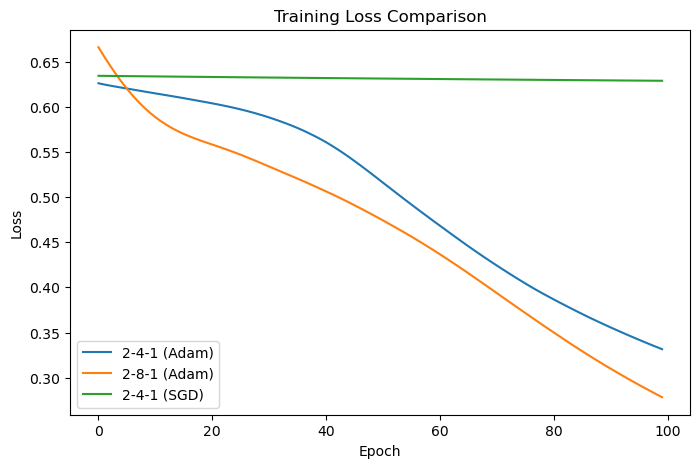

In [2]:
# Cài đặt thư viện
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

# -----------------------
# Tạo dữ liệu
# -----------------------
def generate_class_0(n_samples):
    u = np.random.uniform(0, 1, n_samples)
    theta = np.random.uniform(0, 2*np.pi, n_samples)
    r = np.sqrt(u)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack((x, y))

def generate_class_1(n_samples):
    u = np.random.uniform(0, 1, n_samples)
    theta = np.random.uniform(0, 2*np.pi, n_samples)
    r = np.sqrt(3*u + 1)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack((x, y))

X_class0 = generate_class_0(100)
X_class1 = generate_class_1(200)

y_class0 = np.zeros(100)
y_class1 = np.ones(200)

X = np.vstack((X_class0, X_class1))
y = np.hstack((y_class0, y_class1))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).unsqueeze(1)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).unsqueeze(1)


# -----------------------
# Hàm huấn luyện chung
# -----------------------
def train_model(hidden_size, optimizer_name):

    class ANN(nn.Module):
        def __init__(self):
            super().__init__()
            self.layer1 = nn.Linear(2, hidden_size)
            self.relu = nn.ReLU()
            self.layer2 = nn.Linear(hidden_size, 1)
            self.sigmoid = nn.Sigmoid()

        def forward(self, x):
            x = self.relu(self.layer1(x))
            x = self.sigmoid(self.layer2(x))
            return x

    model = ANN()
    criterion = nn.BCELoss()

    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=0.01)
    else:
        optimizer = optim.SGD(model.parameters(), lr=0.01)

    losses = []

    epochs = 100
    for epoch in range(epochs):
        model.train()

        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return losses


# -----------------------
# Huấn luyện 3 mô hình
# -----------------------
loss_241_adam = train_model(4, "Adam")
loss_281_adam = train_model(8, "Adam")
loss_241_sgd = train_model(4, "SGD")


# -----------------------
# Vẽ đồ thị
# -----------------------
plt.figure(figsize=(8,5))

plt.plot(loss_241_adam, label="2-4-1 (Adam)")
plt.plot(loss_281_adam, label="2-8-1 (Adam)")
plt.plot(loss_241_sgd, label="2-4-1 (SGD)")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

### Phân tích đồ thị mất mát (Loss)
### 1. Trường hợp mất mát giảm nhanh nhất

Mô hình 2-8-1 sử dụng Adam có tốc độ giảm loss nhanh nhất.
Nguyên nhân là:

* Mạng có nhiều nút ẩn hơn, nên khả năng biểu diễn dữ liệu tốt hơn.
* Adam là thuật toán tối ưu hóa thích nghi (adaptive optimizer), giúp cập nhật trọng số hiệu quả và hội tụ nhanh.

### 2. Trường hợp mất mát giảm chậm nhất

Mô hình 2-4-1 sử dụng SGD có tốc độ giảm loss chậm nhất.

Điều này xảy ra vì:

* SGD cập nhật trọng số theo gradient đơn giản với learning rate cố định.
* Không có cơ chế momentum thích nghi như Adam, nên quá trình hội tụ chậm hơn.

### 3. Hiện tượng dao động của mất mát

Trong một số trường hợp, đường loss có thể dao động nhẹ giữa các epoch. Nguyên nhân có thể do:

* Quá trình tối ưu hóa tìm kiếm điểm cực tiểu trong không gian tham số.
* Learning rate chưa tối ưu.
* Gradient thay đổi khi mô hình học các đặc trưng khác nhau của dữ liệu.

Tuy nhiên, nhìn chung loss vẫn có xu hướng giảm dần theo thời gian, cho thấy mô hình đang học được các đặc trưng của dữ liệu.

* Adam giúp giảm loss nhanh và ổn định hơn so với SGD.**
* Tăng số nút trong lớp ẩn (từ 4 lên 8) giúp mô hình học tốt hơn**, do khả năng biểu diễn dữ liệu tăng lên.
* Sự kết hợp mạng lớn hơn + Adam thường cho kết quả tốt nhất trong bài toán này.
